===== TRAFFIC MONITORING SYSTEM STARTED =====
✅ Image loaded successfully


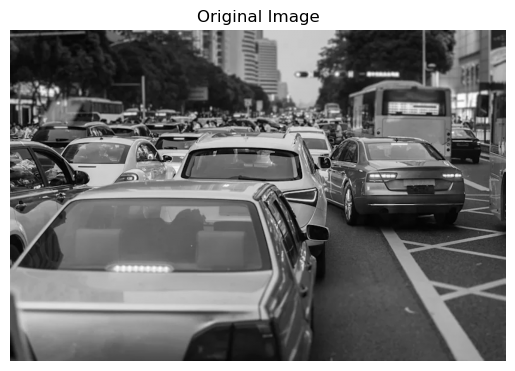


--- TASK 1: EDGE DETECTION ---


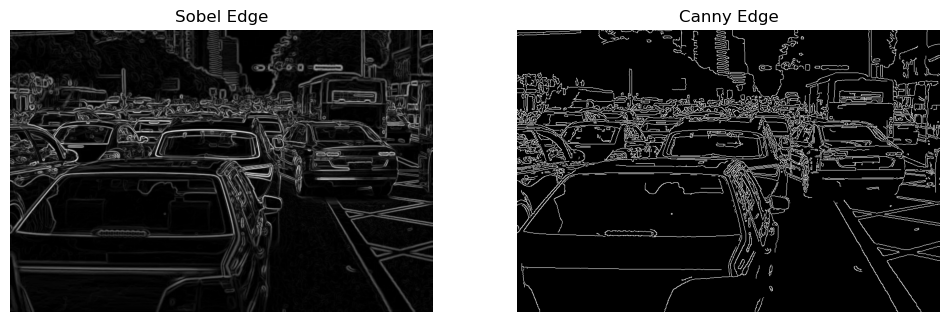


--- TASK 2: OBJECT DETECTION ---
Detected Objects: 717
Area: 1062.50, Perimeter: 1746.85
Area: 658.00, Perimeter: 1247.28
Area: 10075.00, Perimeter: 488.02
Area: 3595.00, Perimeter: 353.14
Area: 2875.50, Perimeter: 1027.35
Area: 1558.50, Perimeter: 220.18


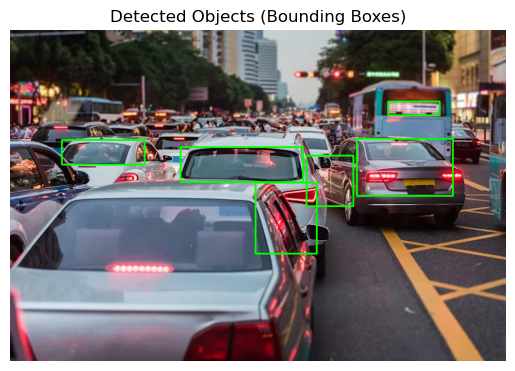


--- TASK 3: FEATURE EXTRACTION ---
Number of Keypoints: 500


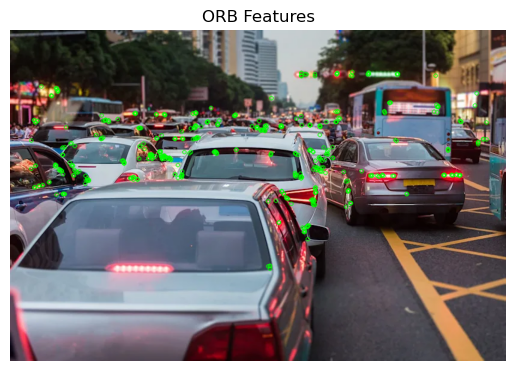


--- TASK 4: COMPARISON ---


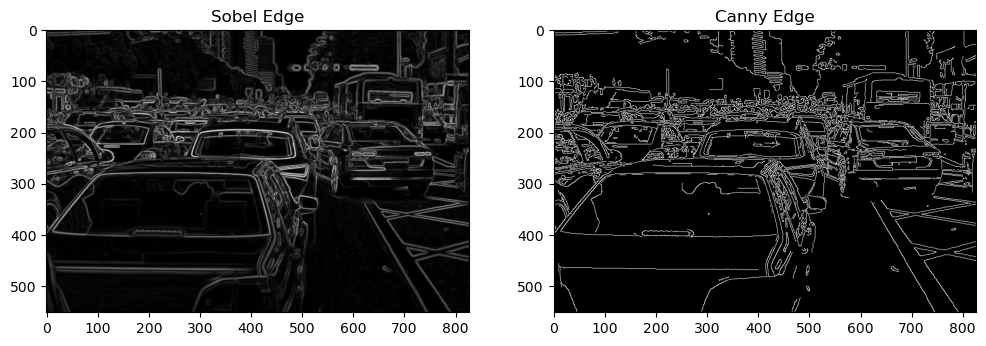

In [ ]:
# ===============================
# Name: Sahil Bhardwaj
# Course: Image Processing & Computer Vision
# Assignment: Feature-Based Traffic Monitoring System
# ===============================

# Install (run once)
# !pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("===== TRAFFIC MONITORING SYSTEM STARTED =====")

# ===============================
# LOAD IMAGE (UPDATE PATH HERE)
# ===============================
image_path = "D:/Downloads/As04/image/traffic.jpg"  

image = cv2.imread(image_path)      

if image is None:
    print("❌ ERROR: Image not loaded. Check path.")
    exit()
else:
    print("✅ Image loaded successfully")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Show original
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


# ===============================
# TASK 1: EDGE DETECTION
# ===============================
print("\n--- TASK 1: EDGE DETECTION ---")

# Sobel
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
sobel = cv2.magnitude(sobelx, sobely)

# Canny
canny = cv2.Canny(gray, 100, 200)

# Display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(canny, cmap='gray')
plt.title("Canny Edge")
plt.axis('off')

plt.show()


# ===============================
# TASK 2: OBJECT REPRESENTATION
# ===============================
print("\n--- TASK 2: OBJECT DETECTION ---")

contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()

print("Detected Objects:", len(contours))

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:   # remove noise
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)

        perimeter = cv2.arcLength(cnt, True)
        print(f"Area: {area:.2f}, Perimeter: {perimeter:.2f}")

# Show bounding boxes
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Objects (Bounding Boxes)")
plt.axis('off')
plt.show()


# ===============================
# TASK 3: FEATURE EXTRACTION (ORB)
# ===============================
print("\n--- TASK 3: FEATURE EXTRACTION ---")

orb = cv2.ORB_create()

keypoints, descriptors = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(image, keypoints, None, color=(0,255,0))

print("Number of Keypoints:", len(keypoints))

plt.imshow(cv2.cvtColor(orb_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Features")
plt.axis('off')
plt.show()


# ===============================
# TASK 4: COMPARISON
# ===============================
print("\n--- TASK 4: COMPARISON ---")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge")

plt.subplot(1,2,2)
plt.imshow(canny, cmap='gray')
plt.title("Canny Edge")

plt.show()


# ===============================
# SAVE OUTPUTS
# ===============================
print("\n--- SAVING OUTPUTS ---")

os.makedirs("outputs", exist_ok=True)

cv2.imwrite("outputs/sobel.png", sobel)
cv2.imwrite("outputs/canny.png", canny)
cv2.imwrite("outputs/contours.png", output)
cv2.imwrite("outputs/orb.png", orb_img)

print("✅ All outputs saved in 'outputs/' folder")

print("\n===== PROJECT COMPLETED SUCCESSFULLY =====")